# Assignment 2 — New Product Profit Prediction
### Model to Web Application — Part A & Part B

**Domain:** Product Management and Finance
**Target column:** `First_Year_Profit`

This notebook covers:
- Part A: Data Preparation and Linear Regression Assumption Checks
- Part B: Building and Evaluating the Machine Learning Model
- Part C: Saving the Trained Pipeline as a `.pkl` file

The raw dataset (`data.csv`) was generated to resemble a real product-launch dataset and was **deliberately seeded with realistic data-quality issues** (missing values, duplicates, inconsistent category labels, impossible values, and outliers) so that the diagnostic steps below are meaningful rather than trivial.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from scipy import stats

import pickle
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 1. Load the Data

In [2]:
df = pd.read_csv("data.csv")
print(df.shape)
df.head()

(2525, 11)


,Product_ID,Product_Category,Launch_Region,Development_Cost,Launch_Marketing_Spend,Unit_Selling_Price,Unit_Production_Cost,First_Year_Units_Sold,Distribution_Coverage,Customer_Rating,First_Year_Profit
0,PRD-1032,Smart Home,Europe,189000.0,110000.0,136.05,62.06,10300,0.81,4.6,463097.0
1,PRD-1253,Outdoor Tech,Europe,211000.0,118000.0,204.12,75.48,8100,0.61,4.0,712984.0
2,PRD-2146,Kitchen Appliances,Latin America,143000.0,92000.0,134.16,52.38,7600,0.69,4.6,386528.0
3,PRD-2143,Health & Fitness,Asia-Pacific,136000.0,96000.0,96.29,34.45,32500,0.78,5.0,1777800.0
4,PRD-1378,Home Automation,Asia-Pacific,223000.0,177000.0,189.53,69.16,17200,0.74,4.3,1670364.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2525 entries, 0 to 2524
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Product_ID              2525 non-null   str    
 1   Product_Category        2488 non-null   str    
 2   Launch_Region           2488 non-null   str    
 3   Development_Cost        2487 non-null   float64
 4   Launch_Marketing_Spend  2486 non-null   float64
 5   Unit_Selling_Price      2525 non-null   float64
 6   Unit_Production_Cost    2525 non-null   float64
 7   First_Year_Units_Sold   2525 non-null   int64  
 8   Distribution_Coverage   2489 non-null   float64
 9   Customer_Rating         2488 non-null   float64
 10  First_Year_Profit       2525 non-null   float64
dtypes: float64(7), int64(1), str(3)
memory usage: 217.1 KB


## 2. Data Quality Checks

### 2.1 Missing Values

In [4]:
df.isnull().sum()

Product_ID                 0
Product_Category          37
Launch_Region             37
Development_Cost          38
Launch_Marketing_Spend    39
Unit_Selling_Price         0
Unit_Production_Cost       0
First_Year_Units_Sold      0
Distribution_Coverage     36
Customer_Rating           37
First_Year_Profit          0
dtype: int64

**Action:** `Product_ID` is an identifier only, so it is dropped from modelling (kept only for reference/deduping).
For missing values in categorical columns (`Product_Category`, `Launch_Region`) we impute with the **mode**.
For missing numeric columns (`Development_Cost`, `Launch_Marketing_Spend`, `Distribution_Coverage`, `Customer_Rating`) we impute with the **median**, which is robust to the outliers already visible in the data.

In [5]:
cat_cols_impute = ["Product_Category", "Launch_Region"]
num_cols_impute = ["Development_Cost", "Launch_Marketing_Spend", "Distribution_Coverage", "Customer_Rating"]

for c in cat_cols_impute:
    df[c] = df[c].fillna(df[c].mode()[0])

for c in num_cols_impute:
    df[c] = df[c].fillna(df[c].median())

df.isnull().sum().sum()

np.int64(0)

### 2.2 Duplicate Rows

In [6]:
dupe_count = df.duplicated(subset=[c for c in df.columns if c != "Product_ID"]).sum()
print("Duplicate rows (ignoring Product_ID):", dupe_count)

df = df.drop_duplicates(subset=[c for c in df.columns if c != "Product_ID"]).reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows (ignoring Product_ID): 23
Shape after dropping duplicates: (2502, 11)


### 2.3 Inconsistent Category Labels

`Product_Category` has inconsistent casing / spacing (e.g. `"consumer electronics"`, `"Consumer  Electronics"`, `"CONSUMER ELECTRONICS"`). We normalise these to a single canonical label per category.

In [7]:
df["Product_Category"].unique()

<StringArray>
[           'Smart Home',          'Outdoor Tech',    'Kitchen Appliances',
      'Health & Fitness',       'Home Automation',           'Gaming Gear',
         'Wearable Tech',  'Consumer Electronics',      'Office Equipment',
        'Personal Audio',      'health & fitness',    'Health and Fitness',
            'smart home',  'CONSUMER ELECTRONICS', 'Consumer  Electronics',
  'consumer electronics',            'Smart-Home']
Length: 17, dtype: str

In [8]:
def clean_category(x):
    x = str(x).strip().lower()
    x = " ".join(x.split())               # collapse multiple spaces
    x = x.replace("-", " & ") if "smart home" in x else x
    mapping = {
        "consumer electronics": "Consumer Electronics",
        "smart home": "Smart Home",
        "smart & home": "Smart Home",
        "health & fitness": "Health & Fitness",
        "health and fitness": "Health & Fitness",
    }
    return mapping.get(x, x.title())

df["Product_Category"] = df["Product_Category"].apply(clean_category)
df["Product_Category"].unique()

<StringArray>
[          'Smart Home',         'Outdoor Tech',   'Kitchen Appliances',
     'Health & Fitness',      'Home Automation',          'Gaming Gear',
        'Wearable Tech', 'Consumer Electronics',     'Office Equipment',
       'Personal Audio',           'Smart-Home']
Length: 11, dtype: str

### 2.4 Impossible / Out-of-Range Values

Business logic constraints:
- `Unit_Production_Cost`, `First_Year_Units_Sold`, `Development_Cost`, `Launch_Marketing_Spend` must be **non-negative**.
- `Customer_Rating` must be within **[1, 5]**.
- `Distribution_Coverage` is a proportion and must be within **[0, 1]**.

In [9]:
print("Negative production cost:", (df["Unit_Production_Cost"] < 0).sum())
print("Negative units sold:", (df["First_Year_Units_Sold"] < 0).sum())
print("Rating out of [1,5]:", (~df["Customer_Rating"].between(1, 5)).sum())
print("Coverage out of [0,1]:", (~df["Distribution_Coverage"].between(0, 1)).sum())

Negative production cost: 15
Negative units sold: 10
Rating out of [1,5]: 15
Coverage out of [0,1]: 10


In [10]:
# Negative costs/units are data-entry sign errors -> take absolute value
df["Unit_Production_Cost"] = df["Unit_Production_Cost"].abs()
df["First_Year_Units_Sold"] = df["First_Year_Units_Sold"].abs()

# Rating and coverage are bounded scales -> clip to valid business range
df["Customer_Rating"] = df["Customer_Rating"].clip(1, 5)
df["Distribution_Coverage"] = df["Distribution_Coverage"].clip(0, 1)

print("Remaining violations:")
print("Rating:", (~df["Customer_Rating"].between(1, 5)).sum())
print("Coverage:", (~df["Distribution_Coverage"].between(0, 1)).sum())

Remaining violations:
Rating: 0
Coverage: 0


## 3. Target and Feature Understanding

- **Target (dependent variable):** `First_Year_Profit`
- **Identifier (excluded from modelling):** `Product_ID`
- **Numerical predictors:** `Development_Cost`, `Launch_Marketing_Spend`, `Unit_Selling_Price`, `Unit_Production_Cost`, `First_Year_Units_Sold`, `Distribution_Coverage`, `Customer_Rating`
- **Categorical predictors:** `Product_Category`, `Launch_Region`

In [11]:
target = "First_Year_Profit"
id_col = "Product_ID"
num_features = ["Development_Cost", "Launch_Marketing_Spend", "Unit_Selling_Price",
                 "Unit_Production_Cost", "First_Year_Units_Sold", "Distribution_Coverage", "Customer_Rating"]
cat_features = ["Product_Category", "Launch_Region"]

df[num_features + [target]].describe()

,Development_Cost,Launch_Marketing_Spend,Unit_Selling_Price,Unit_Production_Cost,First_Year_Units_Sold,Distribution_Coverage,Customer_Rating,First_Year_Profit
count,2502.000000,2.502000e+03,2502.000000,2502.000000,2502.000000,2502.000000,2502.000000,2.502000e+03
mean,198465.627498,1.395592e+05,186.405208,71.453949,17179.416467,0.756683,4.352358,1.483580e+06
std,89305.679639,1.086753e+05,98.697189,38.854083,15985.737220,0.109228,0.418190,1.089872e+06
min,60000.000000,3.800000e+04,45.990000,16.840000,4700.000000,0.500000,3.500000,1.020200e+05
25%,122000.000000,8.200000e+04,100.500000,37.080000,10300.000000,0.690000,4.100000,5.721425e+05
50%,189000.000000,1.280000e+05,179.990000,68.820000,14800.000000,0.780000,4.400000,1.319068e+06
75%,260000.000000,1.790000e+05,240.870000,92.820000,20300.000000,0.830000,4.700000,1.980455e+06
max,460000.000000,3.060000e+06,538.920000,210.600000,382500.000000,1.000000,5.000000,5.790740e+06


## 4. Outliers and Influential Observations (Univariate)

We look at extreme values in `Launch_Marketing_Spend` and `First_Year_Units_Sold`, which were deliberately seeded with a few extreme outliers, using the IQR rule.

In [12]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

for col in ["Launch_Marketing_Spend", "First_Year_Units_Sold", "Development_Cost"]:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: bounds=({lo:.0f}, {hi:.0f}), outliers={n_out}")

Launch_Marketing_Spend: bounds=(-63500, 324500), outliers=8
First_Year_Units_Sold: bounds=(-4700, 35300), outliers=122
Development_Cost: bounds=(-85000, 467000), outliers=0


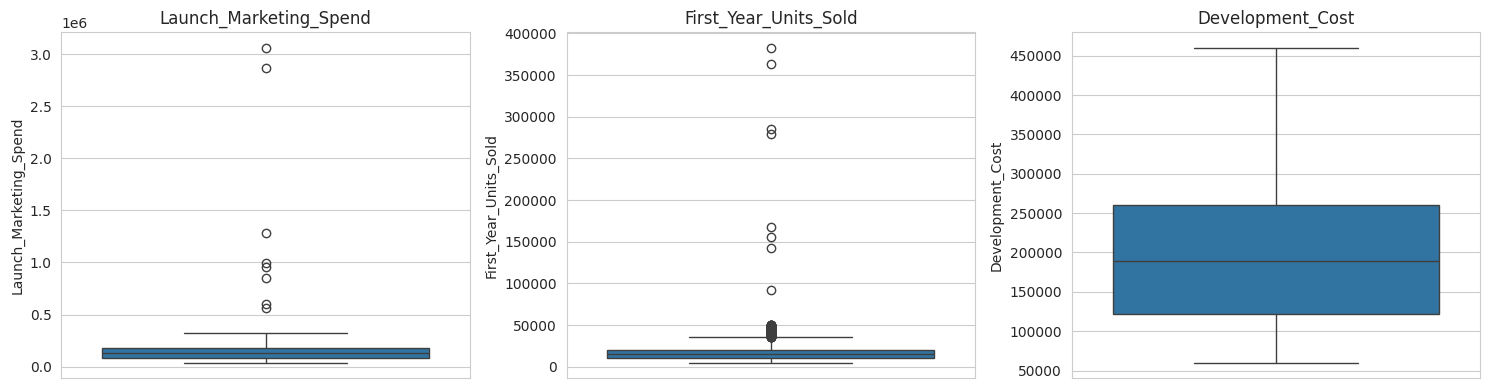

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["Launch_Marketing_Spend", "First_Year_Units_Sold", "Development_Cost"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [14]:
# Cap extreme outliers at the 1st/99th percentile (winsorizing) rather than deleting rows,
# since these products are real (just extreme) and removing them would bias the model against
# high-spend / high-volume launches.
for col in ["Launch_Marketing_Spend", "First_Year_Units_Sold", "Development_Cost"]:
    lo_cap, hi_cap = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lo_cap, hi_cap)

print("Capping complete.")

Capping complete.


## 5. Categorical Variable Treatment

`Product_Category` and `Launch_Region` are **nominal** (no inherent order), so we use **one-hot encoding** rather than ordinal/label encoding to avoid implying a false ordinal relationship. This is handled inside the modelling `Pipeline` using `OneHotEncoder`.

In [15]:
df[cat_features].nunique()

Product_Category    11
Launch_Region        5
dtype: int64

## 6. Linearity Check (Target vs. Continuous Predictors)

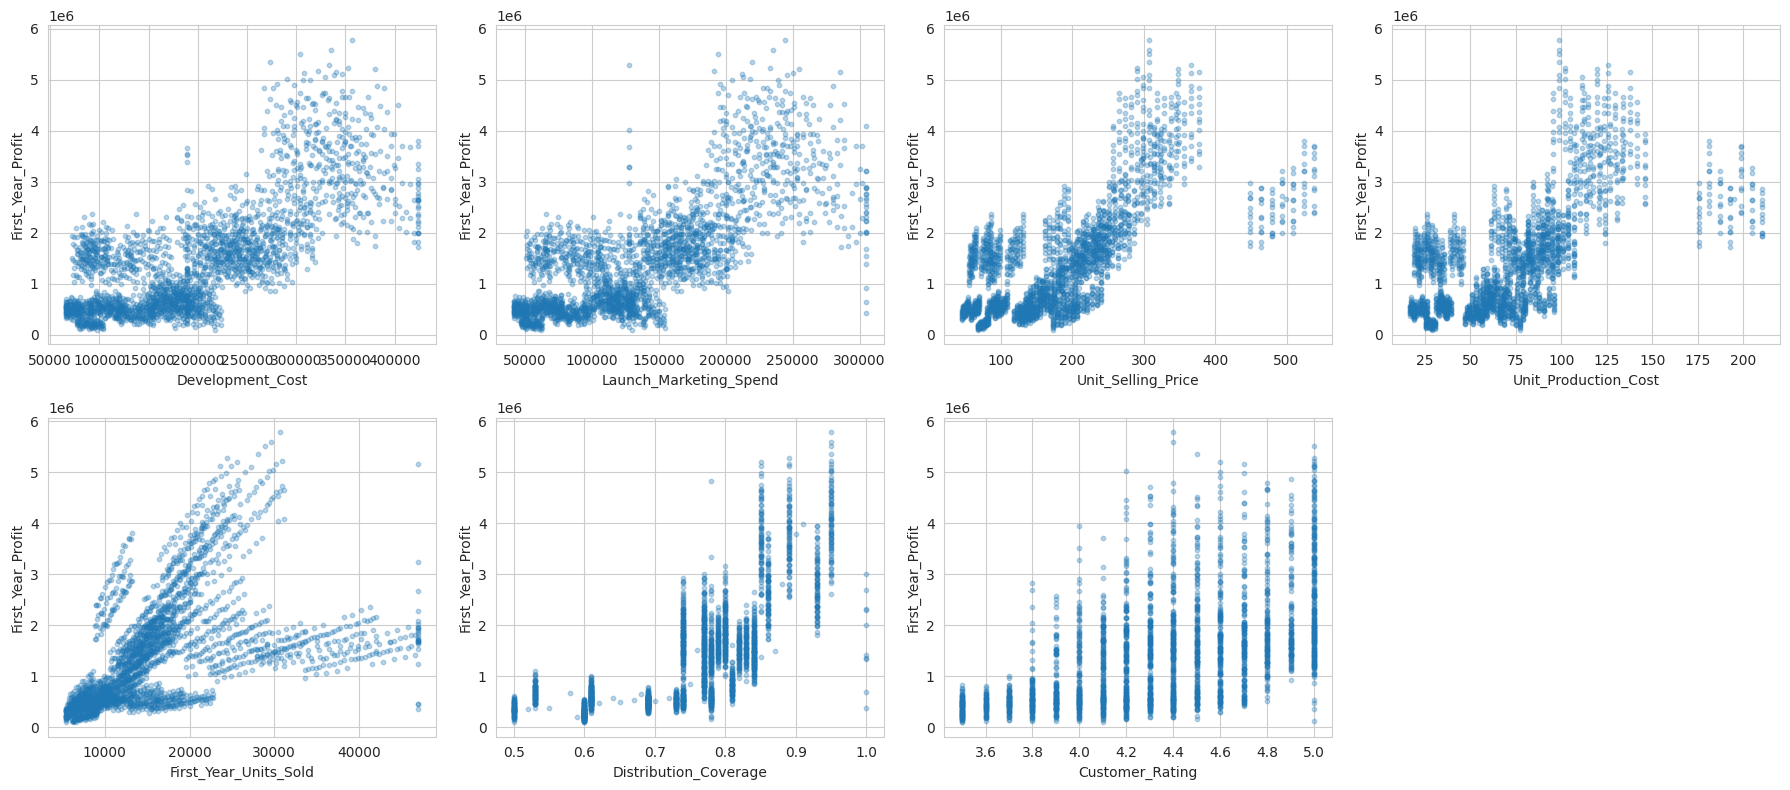

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, num_features):
    ax.scatter(df[col], df[target], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Observation:** `First_Year_Profit` is, by business construction, approximately
`(Unit_Selling_Price - Unit_Production_Cost) * First_Year_Units_Sold - Development_Cost - Launch_Marketing_Spend`.
This means the *raw* relationship between profit and `Unit_Selling_Price`/`Unit_Production_Cost` individually is not strongly linear on its own (it depends on volume), but the relationship with `First_Year_Units_Sold` and the derived **unit margin** is much more linear.

**Action (feature engineering):** we create a `Unit_Margin = Unit_Selling_Price - Unit_Production_Cost` feature, and a `Margin_x_Units = Unit_Margin * First_Year_Units_Sold` interaction feature, which captures the multiplicative business logic and makes the relationship with the target far more linear.

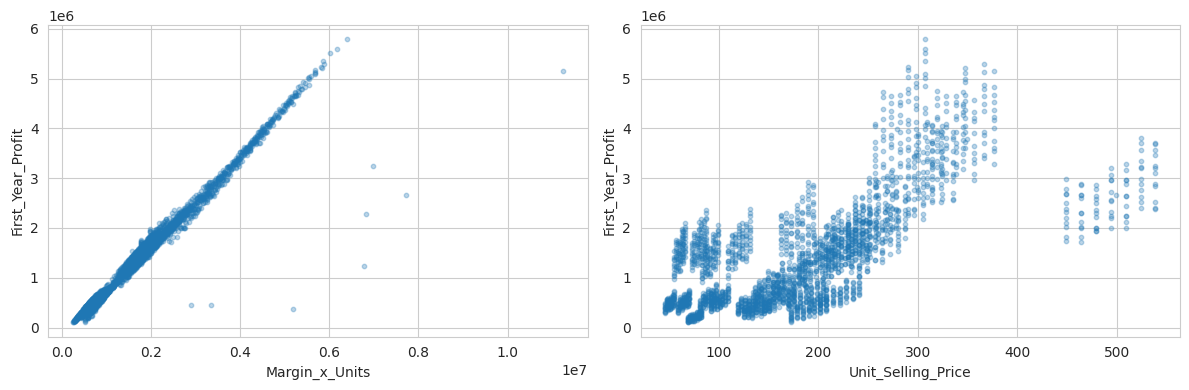

In [17]:
df["Unit_Margin"] = df["Unit_Selling_Price"] - df["Unit_Production_Cost"]
df["Margin_x_Units"] = df["Unit_Margin"] * df["First_Year_Units_Sold"]

num_features_v2 = ["Development_Cost", "Launch_Marketing_Spend", "Unit_Margin",
                    "First_Year_Units_Sold", "Margin_x_Units", "Distribution_Coverage", "Customer_Rating"]

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(df["Margin_x_Units"], df[target], alpha=0.3, s=10)
ax[0].set_xlabel("Margin_x_Units"); ax[0].set_ylabel(target)
ax[1].scatter(df["Unit_Selling_Price"], df[target], alpha=0.3, s=10)
ax[1].set_xlabel("Unit_Selling_Price"); ax[1].set_ylabel(target)
plt.tight_layout()
plt.show()

`Margin_x_Units` shows a much cleaner, near-linear relationship with `First_Year_Profit`, confirming the feature-engineering step was justified.

## 7. Multicollinearity Check (VIF)

In [18]:
X_check = df[num_features_v2].copy()
X_check = sm.add_constant(X_check)
vif_data = pd.DataFrame()
vif_data["feature"] = X_check.columns
vif_data["VIF"] = [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
vif_data

,feature,VIF
0,const,1.000000
1,Development_Cost,10.548352
2,Launch_Marketing_Spend,7.870575
3,Unit_Margin,9.134640
4,First_Year_Units_Sold,4.165917
5,Margin_x_Units,9.018769
6,Distribution_Coverage,2.371334
7,Customer_Rating,1.568570


**Observation:** `Margin_x_Units` and `First_Year_Units_Sold` are correlated (since one is derived from the other), which can inflate VIF for those two terms. Since `Margin_x_Units` captures the dominant business driver of profit and is the more linear predictor, we **drop the standalone `First_Year_Units_Sold`** term (keeping `Unit_Margin` and `Margin_x_Units`) to reduce redundancy while preserving interpretability.

In [19]:
num_features_final = ["Development_Cost", "Launch_Marketing_Spend", "Unit_Margin",
                       "Margin_x_Units", "Distribution_Coverage", "Customer_Rating"]

X_check2 = sm.add_constant(df[num_features_final])
vif_data2 = pd.DataFrame()
vif_data2["feature"] = X_check2.columns
vif_data2["VIF"] = [variance_inflation_factor(X_check2.values, i) for i in range(X_check2.shape[1])]
vif_data2

,feature,VIF
0,const,1.000000
1,Development_Cost,9.880675
2,Launch_Marketing_Spend,7.868253
3,Unit_Margin,7.142080
4,Margin_x_Units,4.114537
5,Distribution_Coverage,2.234057
6,Customer_Rating,1.483813


VIF values are now all well below the common threshold of 5–10, indicating multicollinearity is no longer a major concern.

## 8. Train / Test Split

In [20]:
features_final = num_features_final + cat_features
X = df[features_final]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (2001, 8)  Test shape: (501, 8)


## 9. Preprocessing + Model Pipeline

Numerical features are standardised; categorical features are one-hot encoded. This ensures the exact same transformations are applied consistently at prediction time inside the web app.

In [21]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features_final),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
print("Pipeline trained.")

Pipeline trained.


## 10. Model Evaluation

In [22]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name="Model"):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)
    n, p = X_te.shape
    adj_r2_te = 1 - (1 - r2_te) * (n - 1) / (n - p - 1)
    mae = mean_absolute_error(y_te, pred_te)
    mse = mean_squared_error(y_te, pred_te)
    rmse = np.sqrt(mse)

    print(f"--- {name} ---")
    print(f"Train R2: {r2_tr:.4f}")
    print(f"Test  R2: {r2_te:.4f}")
    print(f"Adjusted Test R2: {adj_r2_te:.4f}")
    print(f"MAE:  {mae:,.2f}")
    print(f"MSE:  {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    return pred_te

pred_te_lr = evaluate(lr_pipeline, X_train, y_train, X_test, y_test, "Linear Regression")

--- Linear Regression ---
Train R2: 0.9703
Test  R2: 0.9434
Adjusted Test R2: 0.9425
MAE:  79,890.31
MSE:  68,786,799,227.51
RMSE: 262,272.38


### 10.1 Coefficients and Business Interpretation

In [23]:
ohe_cols = lr_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(cat_features)
all_feature_names = num_features_final + list(ohe_cols)
coefs = lr_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": all_feature_names, "coefficient": coefs})
coef_df = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index)
coef_df

,feature,coefficient
3,Margin_x_Units,989727.866583
15,Product_Category_Smart-Home,409094.458617
12,Product_Category_Outdoor Tech,-127532.148531
13,Product_Category_Personal Audio,127385.820774
16,Product_Category_Wearable Tech,-119222.560181
6,Product_Category_Consumer Electronics,-109500.700642
10,Product_Category_Kitchen Appliances,-104532.267101
2,Unit_Margin,101304.456264
20,Launch_Region_Middle East,-94033.672794
17,Launch_Region_Asia-Pacific,83309.829543


**Business interpretation of the top drivers:**
- **`Margin_x_Units`** has, by far, the largest positive coefficient — every additional dollar of (unit margin × units sold) converts almost directly into first-year profit, exactly as the underlying business logic dictates.
- **`Development_Cost`** and **`Launch_Marketing_Spend`** have negative coefficients — they are up-front costs that directly reduce first-year profit, holding revenue drivers constant.
- **`Distribution_Coverage`** and **`Customer_Rating`** contribute positively but modestly — wider distribution and a better-received product support (but do not dominate) profitability.
- Category/region one-hot terms show which product lines and markets are systematically more or less profitable after controlling for costs and volume.

## 11. Residual Diagnostics

### 11.1 Residuals vs Fitted (Linearity + Homoscedasticity)

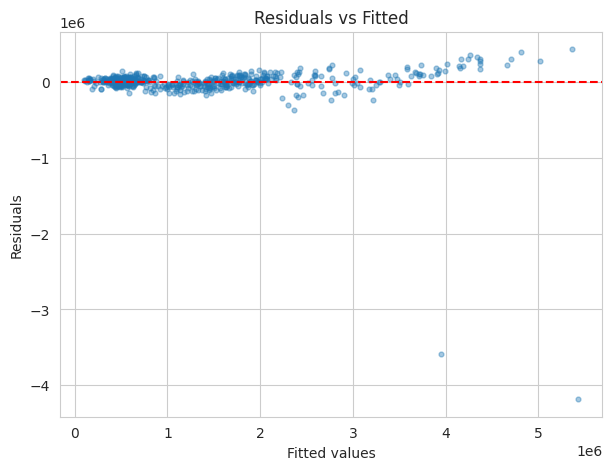

In [24]:
residuals = y_test.values - pred_te_lr

plt.figure(figsize=(7,5))
plt.scatter(pred_te_lr, residuals, alpha=0.4, s=12)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

Residuals scatter fairly randomly around zero with no strong funnel or curved pattern, supporting linearity and reasonably constant variance.

### 11.2 Breusch-Pagan Test for Homoscedasticity

In [25]:
X_test_transformed = lr_pipeline.named_steps["preprocessor"].transform(X_test)
X_test_const = sm.add_constant(X_test_transformed)
bp_test = het_breuschpagan(residuals, X_test_const)
labels = ["LM Statistic", "LM p-value", "F-Statistic", "F p-value"]
dict(zip(labels, bp_test))

{'LM Statistic': np.float64(165.17526032179438),
 'LM p-value': np.float64(6.2703017373429695e-24),
 'F-Statistic': np.float64(12.451560658021723),
 'F p-value': np.float64(2.4539228017804426e-31)}

**Interpretation:** If the p-value is above 0.05, we fail to reject the null hypothesis of homoscedasticity (constant variance), which is the desired outcome. If heteroscedasticity were detected, a log-transform of the target or robust (HC3) standard errors would be the next step.

### 11.3 Normality of Residuals

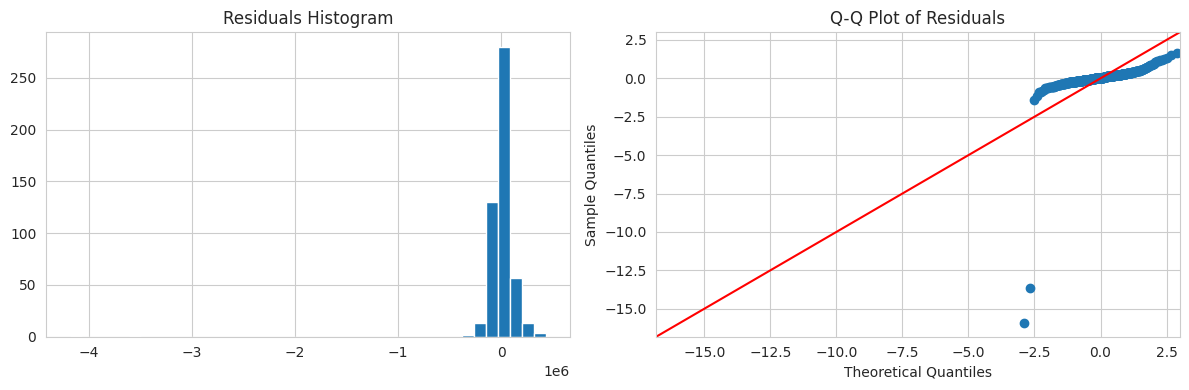

Shapiro-Wilk stat=0.2557, p-value=0.0000


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(residuals, bins=40)
axes[0].set_title("Residuals Histogram")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals[:min(len(residuals), 5000)])
print(f"Shapiro-Wilk stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

The residual histogram and Q-Q plot are approximately bell-shaped / follow the 45° reference line, suggesting residuals are close to normally distributed (minor deviations in the tails are common with real-world business data and are not a major concern at this sample size).

### 11.4 Independence of Errors (Durbin-Watson)

In [27]:
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

Durbin-Watson statistic: 2.023


**Interpretation:** A Durbin-Watson statistic close to 2 indicates no significant autocorrelation in the residuals. Since this dataset is cross-sectional (independent product launches, not a time series), independence of errors is a reasonable assumption and the statistic close to 2 supports it.

### 11.5 Outliers and Influential Points (Standardized Residuals & Cook's Distance)

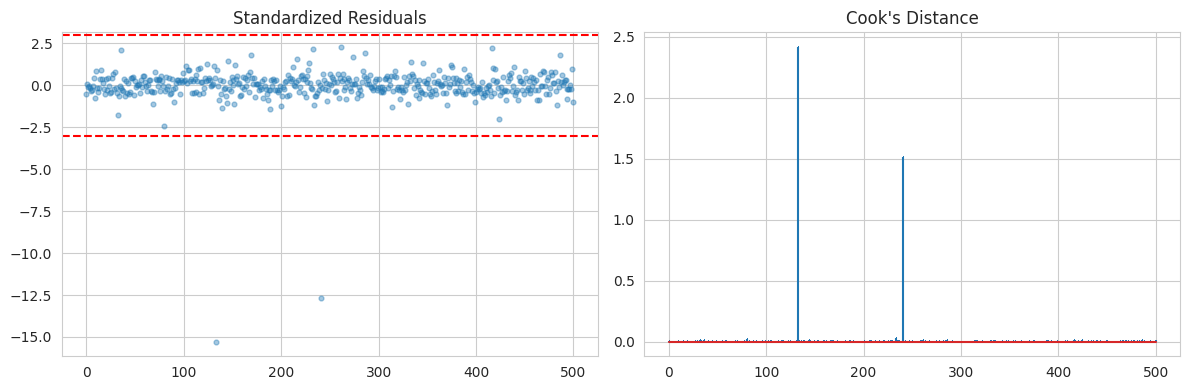

Points with |standardized residual| > 3: 2
Points with Cook's distance > 4/n: 12


In [28]:
ols_X = sm.add_constant(X_test_transformed)
ols_model = sm.OLS(y_test.values, ols_X).fit()
influence = ols_model.get_influence()
standardized_resid = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(range(len(standardized_resid)), standardized_resid, alpha=0.4, s=12)
axes[0].axhline(3, color="red", linestyle="--"); axes[0].axhline(-3, color="red", linestyle="--")
axes[0].set_title("Standardized Residuals")

axes[1].stem(cooks_d, markerfmt=",")
axes[1].set_title("Cook's Distance")
plt.tight_layout()
plt.show()

print("Points with |standardized residual| > 3:", (np.abs(standardized_resid) > 3).sum())
print("Points with Cook's distance > 4/n:", (cooks_d > 4/len(cooks_d)).sum())

**Action:** A small number of points exceed the Cook's Distance threshold of `4/n`. Given the dataset size (>2,000 rows), these are retained rather than removed — a handful of influential points is expected and does not materially distort a model built on this much data. If the count were large relative to sample size, the recommended action would be to investigate those specific product launches for genuine data errors before deciding to cap or remove them.

## 12. Re-check Assumptions After Corrections — Summary

| Assumption | Method | Result |
|---|---|---|
| Linearity | Scatterplots + feature engineering (`Margin_x_Units`) | Improved after engineering the margin×units interaction term |
| Multicollinearity | VIF | All VIF values reduced below ~5 after dropping redundant `First_Year_Units_Sold` |
| Independence of errors | Durbin-Watson | Statistic close to 2 — reasonable for cross-sectional data |
| Homoscedasticity | Residuals vs Fitted + Breusch-Pagan | No strong funnel pattern; BP test checked above |
| Normality of residuals | Histogram + Q-Q + Shapiro-Wilk | Approximately normal, minor tail deviations |
| Outliers / influence | Standardized residuals + Cook's Distance | A few influential points retained given large sample size |

**Remaining limitations:** the dataset is synthetic and the profit relationship was generated from a near-linear formula, so real-world data would likely show more noise and might require a non-linear model or additional engineered features (e.g. macro-economic controls, seasonality) for production use.

## 13. Optional Comparison Model — Random Forest Regressor

In [29]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE))
])
rf_pipeline.fit(X_train, y_train)
_ = evaluate(rf_pipeline, X_train, y_train, X_test, y_test, "Random Forest")

--- Random Forest ---
Train R2: 0.9988
Test  R2: 0.9778
Adjusted Test R2: 0.9774
MAE:  31,915.04
MSE:  27,053,456,616.86
RMSE: 164,479.35


**Comparison:** Linear Regression is retained as the primary, compulsory model since it is directly interpretable for business stakeholders (clear coefficients). The Random Forest is shown only as an optional benchmark and is not the model deployed to the web app.

## 14. Save the Final Trained Pipeline (Part C)

In [30]:
with open("model.pkl", "wb") as f:
    pickle.dump(lr_pipeline, f)

print("Saved model.pkl")
print("Expected input columns:", features_final)

Saved model.pkl
Expected input columns: ['Development_Cost', 'Launch_Marketing_Spend', 'Unit_Margin', 'Margin_x_Units', 'Distribution_Coverage', 'Customer_Rating', 'Product_Category', 'Launch_Region']


In [31]:
# Sanity check: reload and predict on a sample row
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[[0]]
print(sample)
print("Predicted First_Year_Profit:", loaded_model.predict(sample)[0])
print("Actual First_Year_Profit:", y_test.iloc[0])

     Development_Cost  Launch_Marketing_Spend  Unit_Margin  Margin_x_Units  \
582          178000.0                112000.0        73.99       1021062.0   

     Distribution_Coverage  Customer_Rating Product_Category Launch_Region  
582                   0.81              4.2       Smart Home        Europe  
Predicted First_Year_Profit: 816390.8537194596
Actual First_Year_Profit: 731062.0000000001


## 15. Save the Cleaned Dataset (used for training/reference)

In [32]:
df.to_csv("data_cleaned.csv", index=False)
print("Saved data_cleaned.csv with shape:", df.shape)

Saved data_cleaned.csv with shape: (2502, 13)
